# IntegriScan — Exploratory Data Analysis
## Government Procurement Anomaly Detection System
**MSIT 5910 Capstone | University of the People | Edrissa Sarr**

This notebook performs exploratory data analysis on the FY2023 DoD procurement dataset loaded into PostgreSQL.
It produces 6 figures (Fig 5–10) for the technical report and demo video.

In [1]:
# Cell 1: Setup and Library Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

# Load environment variables
load_dotenv()

# Plot styling
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

# Output folder for saving charts
DOCS_FOLDER = os.path.join("..", "docs")
os.makedirs(DOCS_FOLDER, exist_ok=True)

print("Libraries loaded successfully!")
print(f"Charts will be saved to: {os.path.abspath(DOCS_FOLDER)}")

Libraries loaded successfully!
Charts will be saved to: C:\Users\Edrissa SARR\Documents\procurement-anomaly-detection\docs


In [2]:
# Cell 2: Database Connection
connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT", 5432)),
    database=os.getenv("DB_NAME")
)
engine = create_engine(connection_url, pool_pre_ping=True)

with engine.connect() as conn:
    count = conn.execute(text("SELECT COUNT(*) FROM procurement_records")).scalar()
    vendors = conn.execute(text("SELECT COUNT(*) FROM vendors")).scalar()
    synthetic = conn.execute(text(
        "SELECT COUNT(*) FROM procurement_records WHERE is_synthetic_anomaly = TRUE"
    )).scalar()

print(f"Connected to procurement_db successfully!")
print(f"Total procurement records: {count:,}")
print(f"Total unique vendors:      {vendors:,}")
print(f"Synthetic anomalies:       {synthetic:,}")
print(f"Real records:              {count - synthetic:,}")

Connected to procurement_db successfully!
Total procurement records: 47,571
Total unique vendors:      7,783
Synthetic anomalies:       31
Real records:              47,540


In [3]:
# Cell 3: Load Data for EDA
query = """
    SELECT
        pr.record_id,
        pr.total_dollars_obligated,
        pr.zscore_within_category,
        pr.category_mean,
        pr.is_synthetic_anomaly,
        v.recipient_name,
        v.vendor_frequency,
        v.state,
        c.awarding_agency,
        c.naics_code,
        c.naics_description,
        c.award_day_of_year,
        c.award_month,
        c.fiscal_year
    FROM procurement_records pr
    JOIN vendors v ON pr.vendor_id = v.vendor_id
    JOIN contracts c ON pr.contract_id = c.contract_id
    WHERE pr.is_synthetic_anomaly = FALSE
      AND pr.total_dollars_obligated IS NOT NULL
      AND pr.total_dollars_obligated > 0
"""

df = pd.read_sql(query, engine)

print(f"Records loaded for EDA: {len(df):,}")
print(f"\nBasic statistics:")
print(df["total_dollars_obligated"].describe().apply(lambda x: f"${x:,.2f}"))

Records loaded for EDA: 47,540

Basic statistics:
count            $47,540.00
mean         $18,352,761.90
std         $478,888,528.42
min                   $1.04
25%                 $371.06
50%               $2,004.27
75%              $68,939.60
max      $43,519,282,644.60
Name: total_dollars_obligated, dtype: str


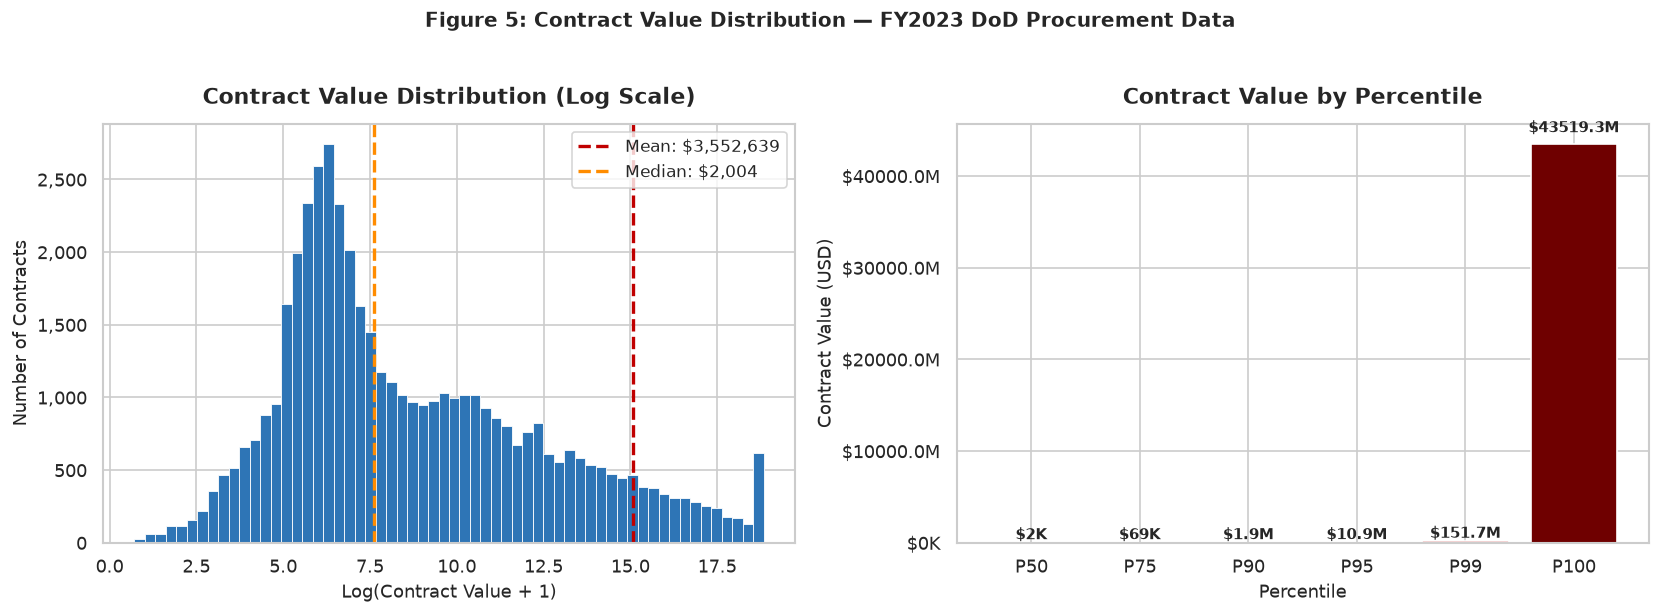

Saved: ..\docs\fig5_contract_value_distribution.png
Mean: $18,352,761.90
Median: $2,004.27


In [4]:
# Cell 4: Figure 5 — Contract Value Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Log scale distribution
ax1 = axes[0]
values = df["total_dollars_obligated"].clip(upper=df["total_dollars_obligated"].quantile(0.99))
ax1.hist(np.log1p(values), bins=60, color="#2E75B6", edgecolor="white", linewidth=0.5)
ax1.set_title("Contract Value Distribution (Log Scale)", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Log(Contract Value + 1)", fontsize=11)
ax1.set_ylabel("Number of Contracts", fontsize=11)
ax1.axvline(np.log1p(values.mean()), color="#C00000", linestyle="--", linewidth=2,
            label=f"Mean: ${values.mean():,.0f}")
ax1.axvline(np.log1p(values.median()), color="#FF8C00", linestyle="--", linewidth=2,
            label=f"Median: ${values.median():,.0f}")
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Right: Percentile breakdown
ax2 = axes[1]
percentiles = [50, 75, 90, 95, 99, 100]
pct_values = [df["total_dollars_obligated"].quantile(p/100) for p in percentiles]
bars = ax2.bar([f"P{p}" for p in percentiles], pct_values,
               color=["#BDD7EE","#9DC3E6","#2E75B6","#1F4E79","#C00000","#6F0000"],
               edgecolor="white")
ax2.set_title("Contract Value by Percentile", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Percentile", fontsize=11)
ax2.set_ylabel("Contract Value (USD)", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K"))
for bar, val in zip(bars, pct_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f"${val/1e6:.1f}M" if val >= 1e6 else f"${val/1e3:.0f}K",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Figure 5: Contract Value Distribution — FY2023 DoD Procurement Data",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
output_path = os.path.join(DOCS_FOLDER, "fig5_contract_value_distribution.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")
print(f"Mean: ${df['total_dollars_obligated'].mean():,.2f}")
print(f"Median: ${df['total_dollars_obligated'].median():,.2f}")

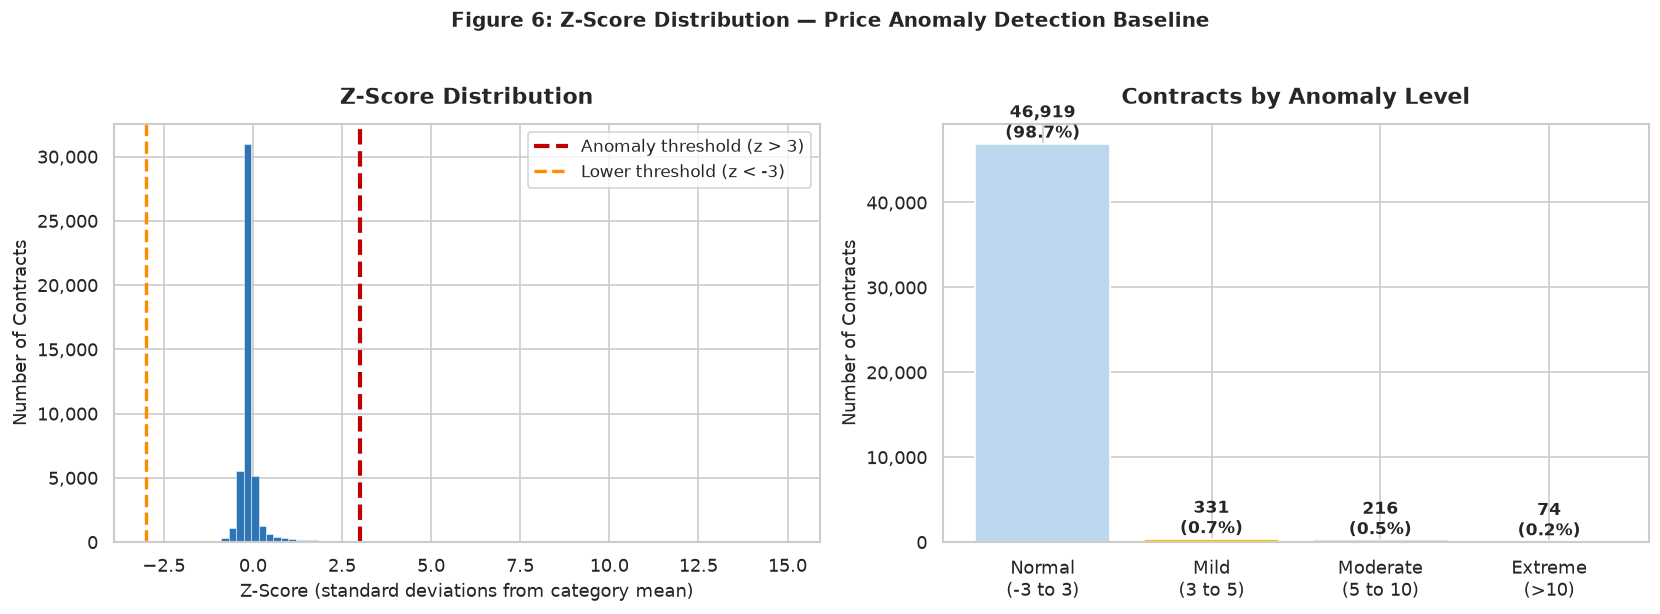

Saved: ..\docs\fig6_zscore_distribution.png
Price outliers (z > 3): 621 (1.3%)


In [5]:
# Cell 5: Figure 6 — Z-Score Distribution
df_z = df[df["zscore_within_category"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
z_clipped = df_z["zscore_within_category"].clip(-5, 15)
ax1.hist(z_clipped, bins=80, color="#2E75B6", edgecolor="white", linewidth=0.3)
ax1.axvline(3, color="#C00000", linestyle="--", linewidth=2.5, label="Anomaly threshold (z > 3)")
ax1.axvline(-3, color="#FF8C00", linestyle="--", linewidth=2, label="Lower threshold (z < -3)")
ax1.set_title("Z-Score Distribution", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Z-Score (standard deviations from category mean)", fontsize=11)
ax1.set_ylabel("Number of Contracts", fontsize=11)
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax2 = axes[1]
normal = len(df_z[df_z["zscore_within_category"].between(-3, 3)])
mild = len(df_z[df_z["zscore_within_category"].between(3, 5)])
moderate = len(df_z[df_z["zscore_within_category"].between(5, 10)])
extreme = len(df_z[df_z["zscore_within_category"] > 10])

categories = ["Normal\n(-3 to 3)", "Mild\n(3 to 5)", "Moderate\n(5 to 10)", "Extreme\n(>10)"]
counts = [normal, mild, moderate, extreme]
colors = ["#BDD7EE", "#FFC000", "#C00000", "#6F0000"]
bars = ax2.bar(categories, counts, color=colors, edgecolor="white")
ax2.set_title("Contracts by Anomaly Level", fontsize=13, fontweight="bold", pad=12)
ax2.set_ylabel("Number of Contracts", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt in zip(bars, counts):
    pct = 100 * cnt / len(df_z)
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Figure 6: Z-Score Distribution — Price Anomaly Detection Baseline",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
output_path = os.path.join(DOCS_FOLDER, "fig6_zscore_distribution.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")
print(f"Price outliers (z > 3): {mild+moderate+extreme:,} ({100*(mild+moderate+extreme)/len(df_z):.1f}%)")

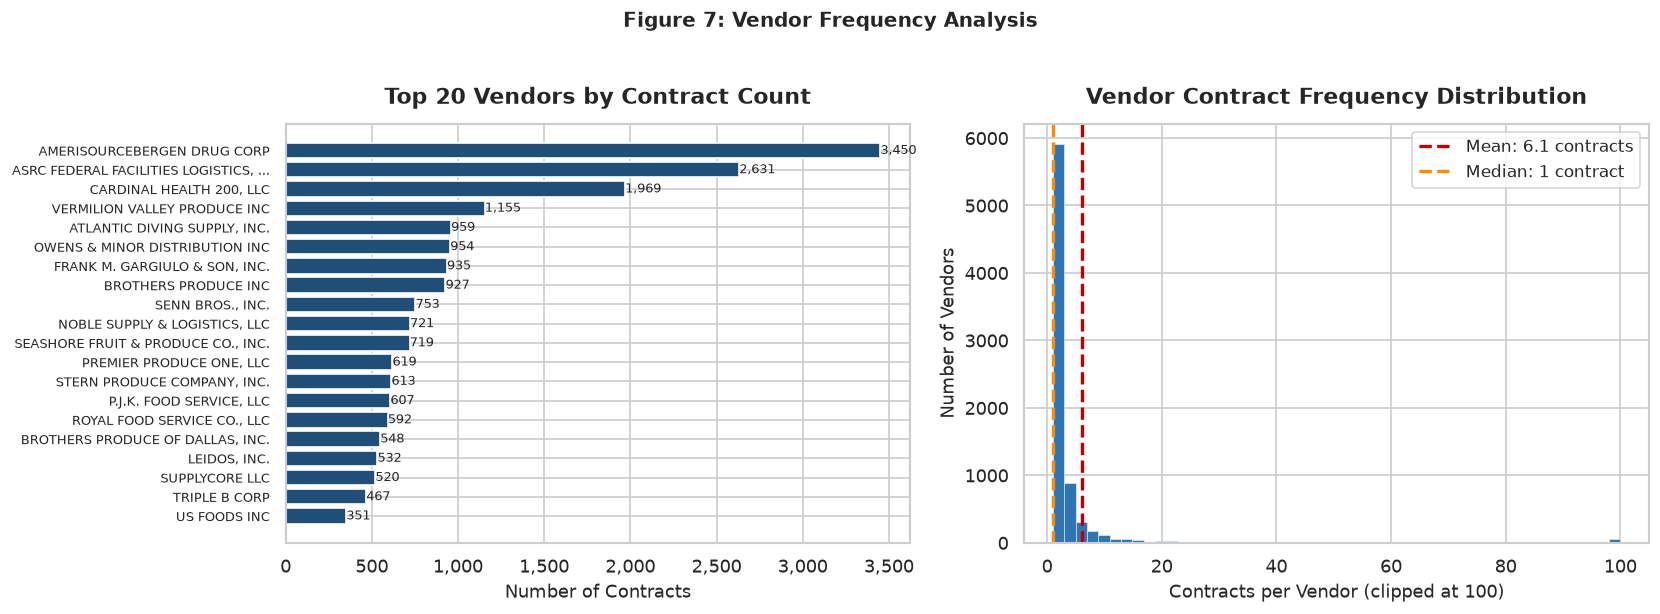

Saved: ..\docs\fig7_vendor_frequency.png
Total unique vendors: 7,777
Max contracts by single vendor: 3,450


In [6]:
# Cell 6: Figure 7 — Vendor Frequency Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_vendors = (df.groupby("recipient_name")["record_id"]
               .count().sort_values(ascending=False).head(20))
short_names = [name[:35] + "..." if len(name) > 35 else name for name in top_vendors.index]

ax1 = axes[0]
bars = ax1.barh(range(len(top_vendors)), top_vendors.values, color="#1F4E79", edgecolor="white")
ax1.set_yticks(range(len(top_vendors)))
ax1.set_yticklabels(short_names, fontsize=8)
ax1.invert_yaxis()
ax1.set_title("Top 20 Vendors by Contract Count", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Number of Contracts", fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, top_vendors.values):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=8)

ax2 = axes[1]
freq_counts = df.groupby("recipient_name")["record_id"].count()
ax2.hist(freq_counts.clip(upper=100), bins=50, color="#2E75B6", edgecolor="white", linewidth=0.3)
ax2.axvline(freq_counts.mean(), color="#C00000", linestyle="--", linewidth=2,
            label=f"Mean: {freq_counts.mean():.1f} contracts")
ax2.axvline(freq_counts.median(), color="#FF8C00", linestyle="--", linewidth=2,
            label=f"Median: {freq_counts.median():.0f} contract")
ax2.set_title("Vendor Contract Frequency Distribution", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Contracts per Vendor (clipped at 100)", fontsize=11)
ax2.set_ylabel("Number of Vendors", fontsize=11)
ax2.legend(fontsize=10)

plt.suptitle("Figure 7: Vendor Frequency Analysis", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
output_path = os.path.join(DOCS_FOLDER, "fig7_vendor_frequency.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")
print(f"Total unique vendors: {freq_counts.count():,}")
print(f"Max contracts by single vendor: {freq_counts.max():,}")

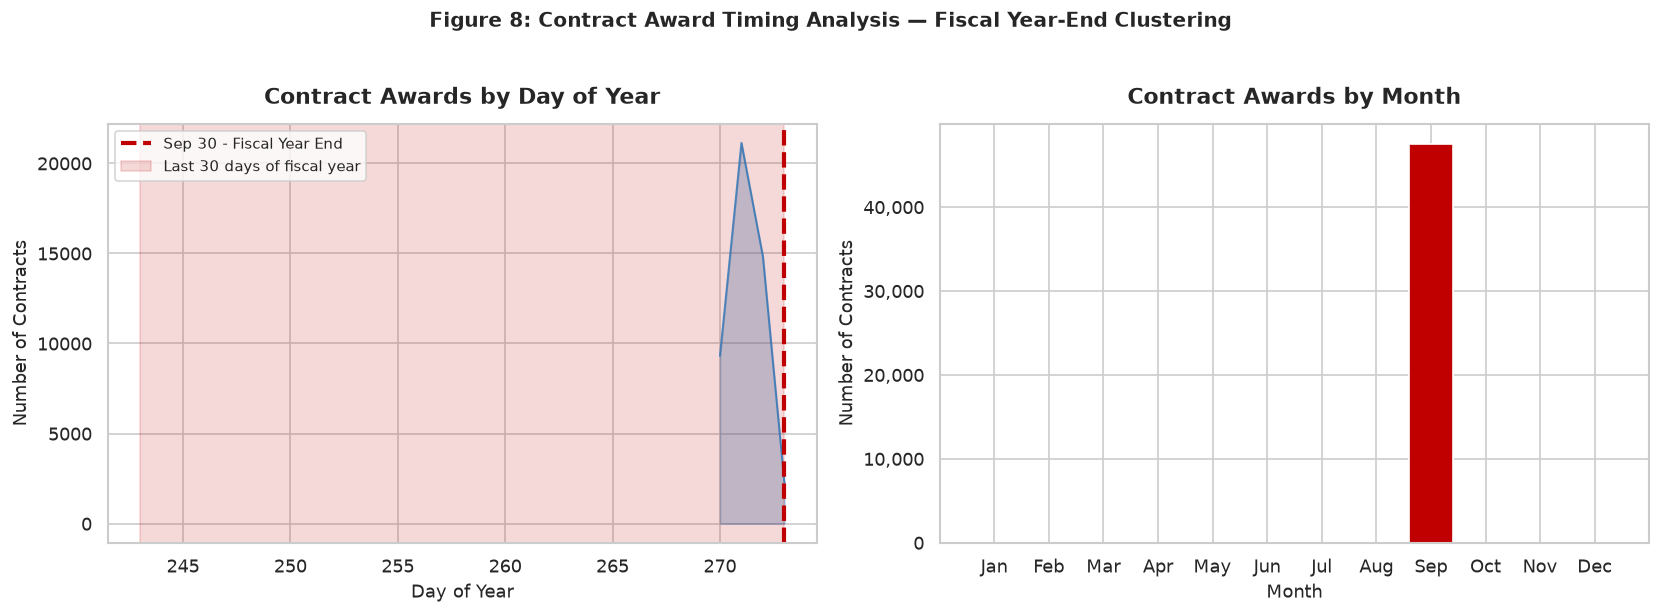

Saved: ..\docs\fig8_timing_analysis.png
Awards in last 30 days of fiscal year: 47,540 (100.0%)


In [7]:
# Cell 7: Figure 8 — Fiscal Year-End Timing Analysis
df_time = df[df["award_day_of_year"].notna()].copy()
df_time["award_day_of_year"] = df_time["award_day_of_year"].astype(int)
df_time["award_month"] = df_time["award_month"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
day_counts = df_time.groupby("award_day_of_year")["record_id"].count()
ax1.plot(day_counts.index, day_counts.values, color="#2E75B6", linewidth=1.2, alpha=0.8)
ax1.fill_between(day_counts.index, day_counts.values, alpha=0.3, color="#2E75B6")
ax1.axvline(273, color="#C00000", linestyle="--", linewidth=2.5, label="Sep 30 - Fiscal Year End")
ax1.axvspan(243, 273, alpha=0.15, color="#C00000", label="Last 30 days of fiscal year")
ax1.set_title("Contract Awards by Day of Year", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Day of Year", fontsize=11)
ax1.set_ylabel("Number of Contracts", fontsize=11)
ax1.legend(fontsize=9)

ax2 = axes[1]
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_counts = df_time.groupby("award_month")["record_id"].count().reindex(range(1,13), fill_value=0)
colors_m = ["#C00000" if m == 9 else "#2E75B6" for m in range(1, 13)]
ax2.bar(month_names, month_counts.values, color=colors_m, edgecolor="white")
ax2.set_title("Contract Awards by Month", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Month", fontsize=11)
ax2.set_ylabel("Number of Contracts", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Figure 8: Contract Award Timing Analysis — Fiscal Year-End Clustering",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
output_path = os.path.join(DOCS_FOLDER, "fig8_timing_analysis.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
last_30 = len(df_time[df_time["award_day_of_year"].between(243, 273)])
print(f"Saved: {output_path}")
print(f"Awards in last 30 days of fiscal year: {last_30:,} ({100*last_30/len(df_time):.1f}%)")

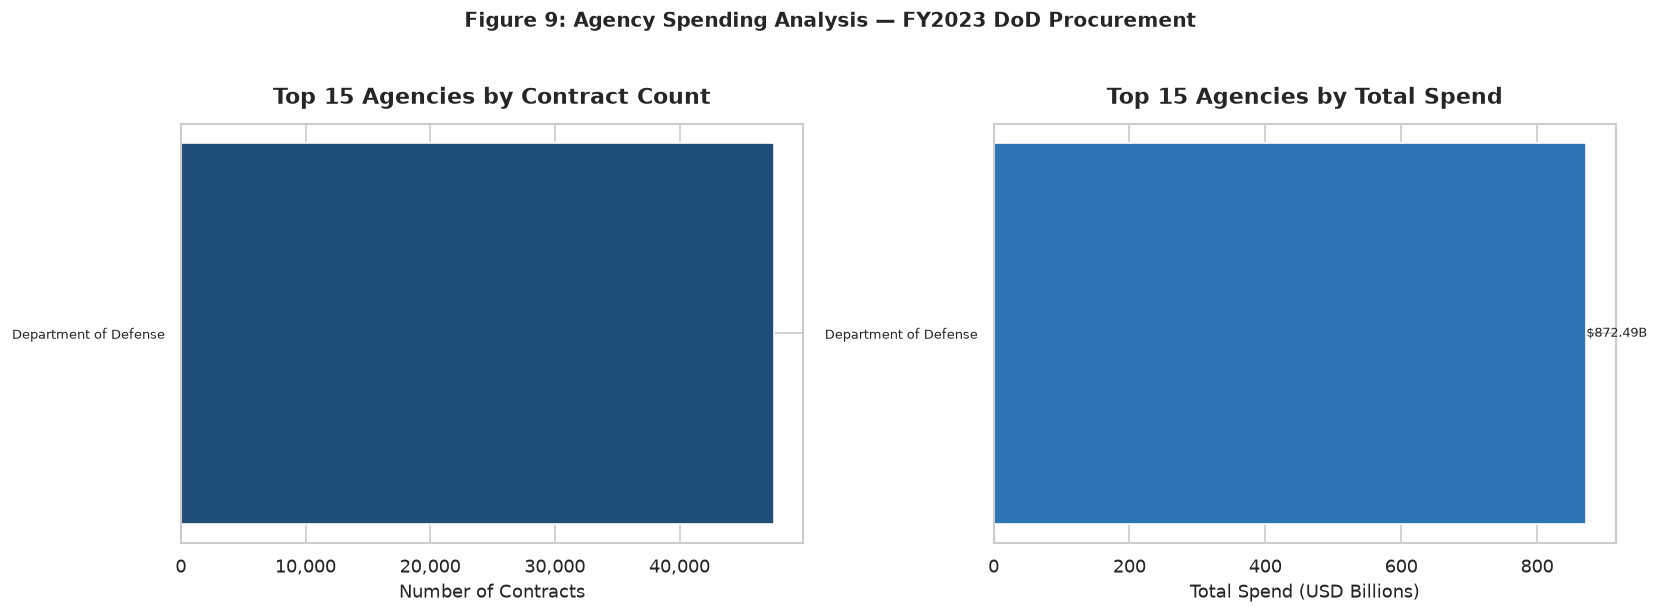

Saved: ..\docs\fig9_agency_analysis.png
Total agencies: 1


In [8]:
# Cell 8: Figure 9 — Agency Spending Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

agency_data = (df.groupby("awarding_agency")
               .agg(contracts=("record_id","count"),
                    total_spend=("total_dollars_obligated","sum"))
               .sort_values("contracts", ascending=False)
               .head(15))
agency_data.index = [name[:40]+"..." if len(name)>40 else name for name in agency_data.index]

ax1 = axes[0]
ax1.barh(range(len(agency_data)), agency_data["contracts"].values, color="#1F4E79", edgecolor="white")
ax1.set_yticks(range(len(agency_data)))
ax1.set_yticklabels(agency_data.index, fontsize=8)
ax1.invert_yaxis()
ax1.set_title("Top 15 Agencies by Contract Count", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Number of Contracts", fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax2 = axes[1]
bars2 = ax2.barh(range(len(agency_data)), agency_data["total_spend"].values/1e9,
                 color="#2E75B6", edgecolor="white")
ax2.set_yticks(range(len(agency_data)))
ax2.set_yticklabels(agency_data.index, fontsize=8)
ax2.invert_yaxis()
ax2.set_title("Top 15 Agencies by Total Spend", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Total Spend (USD Billions)", fontsize=11)
for bar, val in zip(bars2, agency_data["total_spend"].values):
    ax2.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
             f"${val/1e9:.2f}B", va="center", fontsize=8)

plt.suptitle("Figure 9: Agency Spending Analysis — FY2023 DoD Procurement",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
output_path = os.path.join(DOCS_FOLDER, "fig9_agency_analysis.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")
print(f"Total agencies: {df['awarding_agency'].nunique():,}")

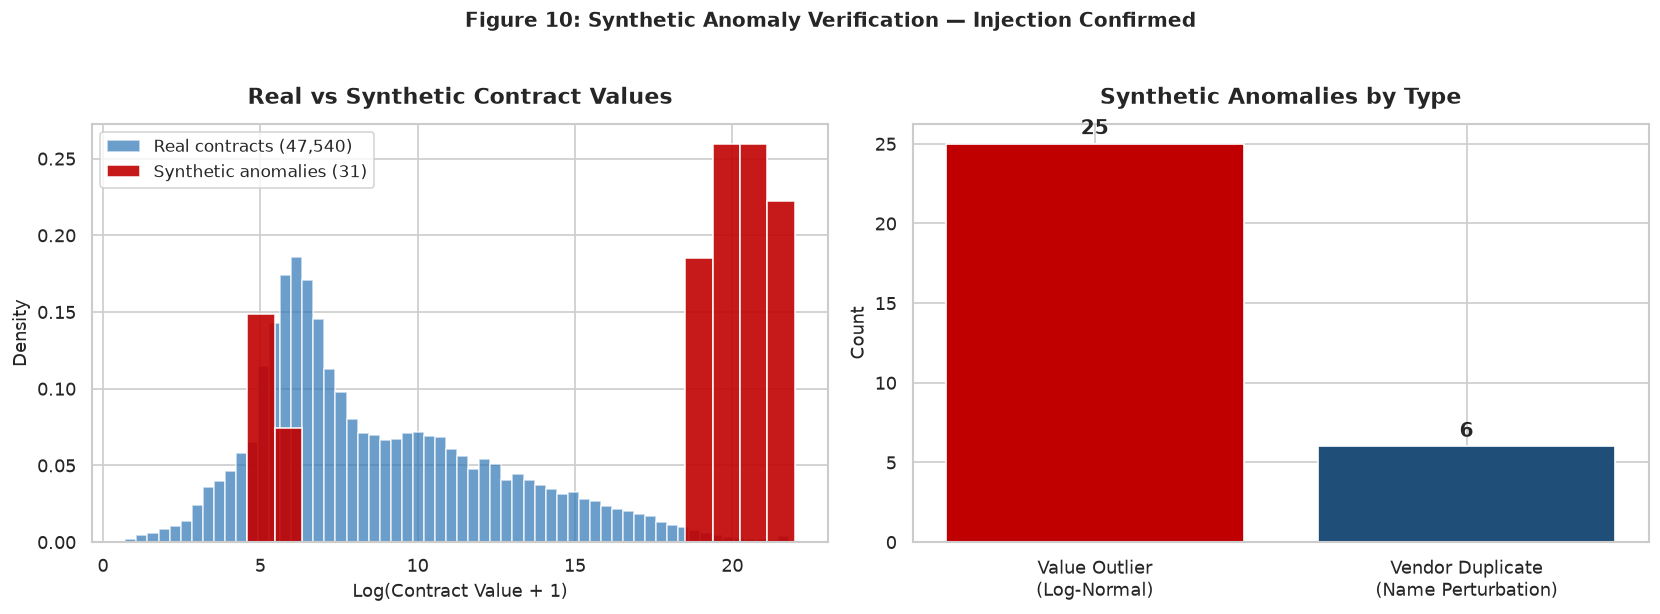

Saved: ..\docs\fig10_synthetic_verification.png
Real records: 47,540 | Synthetic: 31


In [9]:
# Cell 9: Figure 10 — Synthetic Anomaly Verification
df_all = pd.read_sql("""
    SELECT pr.total_dollars_obligated, pr.zscore_within_category,
           pr.is_synthetic_anomaly, pr.synthetic_anomaly_type
    FROM procurement_records pr
    WHERE pr.total_dollars_obligated IS NOT NULL AND pr.total_dollars_obligated > 0
""", engine)

df_real = df_all[df_all["is_synthetic_anomaly"] == False]
df_synth = df_all[df_all["is_synthetic_anomaly"] == True]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
real_vals = np.log1p(df_real["total_dollars_obligated"].clip(
    upper=df_real["total_dollars_obligated"].quantile(0.999)))
ax1.hist(real_vals, bins=60, alpha=0.7, color="#2E75B6",
         label=f"Real contracts ({len(df_real):,})", density=True)
if len(df_synth) > 0:
    synth_vals = np.log1p(df_synth["total_dollars_obligated"])
    ax1.hist(synth_vals, bins=20, alpha=0.9, color="#C00000",
             label=f"Synthetic anomalies ({len(df_synth):,})", density=True)
ax1.set_title("Real vs Synthetic Contract Values", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Log(Contract Value + 1)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.legend(fontsize=10)

ax2 = axes[1]
if len(df_synth) > 0:
    type_counts = df_synth["synthetic_anomaly_type"].value_counts()
    type_labels = {
        "value_outlier_lognormal": "Value Outlier\n(Log-Normal)",
        "vendor_duplicate_perturbation": "Vendor Duplicate\n(Name Perturbation)"
    }
    display_labels = [type_labels.get(t, t) for t in type_counts.index]
    bars = ax2.bar(display_labels, type_counts.values,
                   color=["#C00000","#1F4E79"][:len(type_counts)], edgecolor="white")
    ax2.set_title("Synthetic Anomalies by Type", fontsize=13, fontweight="bold", pad=12)
    ax2.set_ylabel("Count", fontsize=11)
    for bar, val in zip(bars, type_counts.values):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(val), ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.suptitle("Figure 10: Synthetic Anomaly Verification — Injection Confirmed",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
output_path = os.path.join(DOCS_FOLDER, "fig10_synthetic_verification.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")
print(f"Real records: {len(df_real):,} | Synthetic: {len(df_synth):,}")

In [10]:
# Cell 10: EDA Summary
print("=" * 60)
print("EDA COMPLETE - KEY FINDINGS")
print("=" * 60)
total = len(df)
outliers = len(df[df["zscore_within_category"] > 3])
vendors_total = df["recipient_name"].nunique()
top_agency = df.groupby("awarding_agency")["record_id"].count().idxmax()
last_30 = len(df[df["award_day_of_year"].between(243, 273)])
print(f"Dataset: USASpending.gov FY2023 DoD Contracts")
print(f"Records analyzed:        {total:,}")
print(f"Unique vendors:          {vendors_total:,}")
print(f"Price outliers (z > 3):  {outliers:,} ({100*outliers/total:.1f}%)")
print(f"Top agency:              {top_agency[:50]}")
print(f"Year-end awards (30d):   {last_30:,} ({100*last_30/total:.1f}%)")
print()
print("Charts saved to /docs/ folder:")
for i in range(5, 11):
    names = {5:"contract_value_distribution", 6:"zscore_distribution",
             7:"vendor_frequency", 8:"timing_analysis",
             9:"agency_analysis", 10:"synthetic_verification"}
    print(f"  fig{i}_{names[i]}.png")
print()
print("Ready for Unit 5: ML Module Implementation")
print("=" * 60)

EDA COMPLETE - KEY FINDINGS
Dataset: USASpending.gov FY2023 DoD Contracts
Records analyzed:        47,540
Unique vendors:          7,777
Price outliers (z > 3):  621 (1.3%)
Top agency:              Department of Defense
Year-end awards (30d):   47,540 (100.0%)

Charts saved to /docs/ folder:
  fig5_contract_value_distribution.png
  fig6_zscore_distribution.png
  fig7_vendor_frequency.png
  fig8_timing_analysis.png
  fig9_agency_analysis.png
  fig10_synthetic_verification.png

Ready for Unit 5: ML Module Implementation
